# Chapter 01 — The Patent Document Model

*Where we are:* **document representation** — the base of the pipeline. Everything downstream
(chunking, retrieval, citations, provenance) speaks the vocabulary defined here.

```
 →[ Canonical document model ]→ normalization → chunking → retrieval → generation
```

### Concept: a patent is structured data, not a text blob

**Intuition.** A patent has *parts that mean different things*: bibliographic metadata, an
abstract, a multi-section description, and — legally the crown jewels — **claims**, split into
*independent* and *dependent*. **Why it exists:** patent search, prior-art analysis and citation
depend on those boundaries. **Failure mode of flat text:** concatenate everything into one string
and you can no longer ask "which *independent claim* covers X?", filter by CPC, or cite "claim 3
of US…". You also lose the anchors needed to point a citation back to a source region.

In [1]:
# === Chapter 01 · standard bootstrap (identical pattern in every notebook) ===
# Runs standalone on a fresh Google Colab VM *or* a local checkout.
import os, sys, subprocess

REPO_URL = "https://github.com/rsalehin/patent-rag-masterclass"
NEED_OCR = False
IN_COLAB = "google.colab" in sys.modules


def _clone_repo(url, target):
    """Clone the repo on Colab. For a PRIVATE repo, authenticate with a GitHub token read from
    Colab Secrets (key 'GITHUB_TOKEN') or the GITHUB_TOKEN env var. The token is never printed."""
    token = None
    try:
        from google.colab import userdata  # type: ignore
        token = userdata.get("GITHUB_TOKEN")
    except Exception:
        token = os.environ.get("GITHUB_TOKEN")
    auth_url = url
    if token and url.startswith("https://github.com/"):
        auth_url = url.replace("https://github.com/", f"https://{token}@github.com/")
    r = subprocess.run(["git", "clone", "--depth", "1", auth_url, target],
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)  # avoid leaking the token
    if r.returncode != 0:
        raise RuntimeError(
            "git clone failed. This is a PRIVATE repo, so Colab needs a GitHub token:\n"
            "  1) Create a token (scope: repo) at https://github.com/settings/tokens\n"
            "  2) In Colab, open the key icon (Secrets) in the left sidebar, add a secret named\n"
            "     GITHUB_TOKEN, paste the token, and enable 'Notebook access'.\n"
            "  3) Re-run this cell.\n"
            "  (Alternatively, make the GitHub repo public — then no token is needed.)")


if IN_COLAB:
    target = "/content/patent-rag-masterclass"
    if not os.path.isdir(target):
        if not REPO_URL:
            raise RuntimeError("Set REPO_URL to this repo's GitHub URL (see README.md).")
        _clone_repo(REPO_URL, target)
    os.chdir(target)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    if NEED_OCR:
        subprocess.run(["apt-get", "install", "-y", "-q", "tesseract-ocr"], check=False)

# Ensure the repo root (containing patentrag/) is importable.
for _cand in [os.getcwd()] + [os.path.dirname(os.getcwd())]:
    if os.path.isdir(os.path.join(_cand, "patentrag")):
        if _cand not in sys.path:
            sys.path.insert(0, _cand)
        break

from patentrag import bootstrap as bs
bs.setup_environment(REPO_URL, need_ocr=NEED_OCR)
bs.set_seeds()
_env = bs.environment_report()
print("Chapter 01 bootstrap OK")
print("  Python", _env["python"], "| Colab:", _env["in_colab"], "| CPU cores:", _env["cpu_count"])
print("  torch", _env["torch"], "| CUDA:", _env["cuda_available"], "| tesseract:", _env["tesseract"])

Chapter 01 bootstrap OK
  Python 3.12.10 | Colab: False | CPU cores: 24
  torch 2.12.0.dev20260304+cu130 | CUDA: True | tesseract: True


### The canonical model (implemented in `patentrag/models.py`)

We use **Pydantic** (validation + typing + serialization). The core types:

- `PatentDocument` — biblio + `sections` + `claims`
- `PatentSection` / `PatentClaim` — structure with kinds & dependency
- `PatentChunk` — a retrieval/citation unit (Chapter 05) carrying offsets + an anchor
- `SourceAnchor` / `BoundingBox` — provenance back to XML node / PDF region
- `Citation` — a machine-checkable claim-of-support with a stable label

The first time a concept appears we show it *visibly*; thereafter chapters import it.

In [2]:
import inspect
from patentrag import models
# The field structure of the canonical document (what we chose to preserve).
for name in ["PatentDocument", "PatentClaim", "PatentSection", "SourceAnchor", "Citation"]:
    cls = getattr(models, name)
    fields = list(cls.model_fields) if hasattr(cls, "model_fields") else []
    print(f"{name:16} fields: {fields}")

PatentDocument   fields: ['doc_id', 'publication_number', 'application_number', 'title', 'abstract', 'assignees', 'inventors', 'priority_date', 'filing_date', 'publication_date', 'cpc', 'ipc', 'citations', 'language', 'claims', 'sections', 'access_level', 'source']
PatentClaim      fields: ['number', 'text', 'dependent_on']
PatentSection    fields: ['section_id', 'kind', 'heading', 'text', 'order', 'anchor']
SourceAnchor     fields: ['document_id', 'section_id', 'xpath', 'node_id', 'page', 'bbox', 'orig_start', 'orig_end', 'norm_start', 'norm_end']
Citation         fields: ['document_id', 'publication_number', 'section', 'claim_number', 'chunk_id', 'anchor', 'quote']


### Load the real corpus into the model

`from_corpus_json` maps each bundled record into a `PatentDocument`, inferring section *kinds*
from real headings (TECHNICAL FIELD → `technical_field`, etc.) and preserving claim dependency.

In [3]:
import pandas as pd
docs = bs.ensure("docs_canonical")
d = next(x for x in docs if x.doc_id == "US10261954B2")   # "Optimizing search result snippet selection"
print("Title     :", d.title)
print("Assignee  :", d.assignees[0] if d.assignees else "—")
print("CPC       :", d.cpc[:3], "| sections (top-level):", d.cpc_sections)
print("Dates     :", d.priority_date, d.filing_date, d.publication_date)
print("Claims    :", len(d.claims), "->", len(d.independent_claims), "independent")
print("Sections  :")
pd.DataFrame([{"order": s.order, "kind": s.kind.value, "heading": s.heading[:40],
               "chars": len(s.text)} for s in d.sections])

Title     : Optimizing search result snippet selection
Assignee  : Dropbox Inc
CPC       : ['G06F', 'G06F16/00', 'G06F16/20'] | sections (top-level): ['G']
Dates     : 2016-12-30 2017-06-30 2019-04-16
Claims    : 19 -> 3 independent
Sections  :


,order,kind,heading,chars
0,0,abstract,ABSTRACT,518
1,1,other,PRIORITY CLAIM,206
2,2,technical_field,TECHNICAL FIELD,209
3,3,background,BACKGROUND,5645
4,4,brief_description_drawings,BRIEF DESCRIPTION OF THE DRAWINGS,1581
5,5,detailed_description,DETAILED DESCRIPTION,433
6,6,other,General Overview,4561
7,7,other,Computing Environment,2113
8,8,other,Indexer and Document Index,1693
9,9,other,Parsing Documents,1353


### Independent vs dependent claims — a distinction flat text erases

A **dependent** claim references another ("The method of claim 1, wherein…"); an **independent**
claim stands alone and defines the broadest protection. Our model records `dependent_on`, so we
can reconstruct the claim tree.

In [4]:
for c in d.claims[:6]:
    tag = "IND " if c.is_independent else f"dep→{c.dependent_on}"
    print(f"  claim {c.number:>2} [{tag}] {c.text[:80]}")
print(f"\nindependent claims in this patent: {[c.number for c in d.independent_claims]}")

  claim  1 [IND ] A method performed by a computing system comprising one or more processors and s
  claim  2 [dep→1] The method of claim 1 , further comprising: based at least in part on the user c
  claim  3 [dep→1] The method of claim 1 , further comprising: based at least in part on the user c
  claim  4 [dep→1] The method of claim 1 , wherein: the user dwell time is based at least in part o
  claim  5 [dep→1] The method of claim 1 , wherein: the adjusting the snippet selection model to re
  claim  6 [dep→1] The method of claim 1 , wherein: the adjusting the snippet selection model to re

independent claims in this patent: [1, 7, 12]


### Visualize the document hierarchy

The structure the model preserves, drawn for one patent: sections sized by text length, and the
claim tree (independent roots with their dependents).

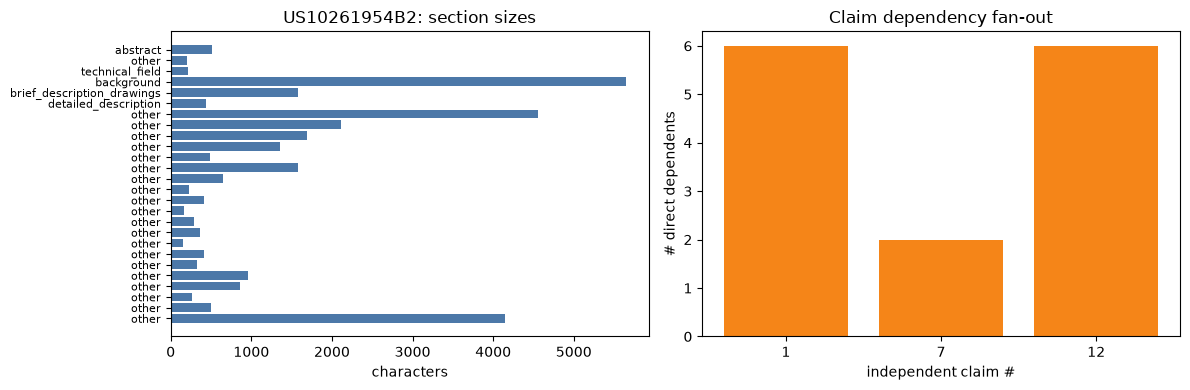

In [5]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# sections by size
labels = [s.kind.value for s in d.sections]
sizes = [len(s.text) for s in d.sections]
ax1.barh(range(len(labels)), sizes, color="#4C78A8")
ax1.set_yticks(range(len(labels))); ax1.set_yticklabels(labels, fontsize=8)
ax1.set_xlabel("characters"); ax1.set_title(f"{d.doc_id}: section sizes"); ax1.invert_yaxis()

# claim tree: independent claims and count of dependents
from collections import Counter
dep_counts = Counter(c.dependent_on for c in d.claims if c.dependent_on)
indep = [c.number for c in d.independent_claims]
ax2.bar([str(n) for n in indep], [sum(1 for c in d.claims if c.dependent_on == n) for n in indep], color="#F58518")
ax2.set_xlabel("independent claim #"); ax2.set_ylabel("# direct dependents")
ax2.set_title("Claim dependency fan-out")
plt.tight_layout(); plt.show()

### Corpus-wide view

Across the whole corpus, how much of a patent is claims vs description, and how the
independent/dependent split looks.

In [6]:
rows = [{"doc": x.doc_id,
         "claim_chars": sum(len(c.text) for c in x.claims),
         "desc_chars": sum(len(s.text) for s in x.sections),
         "n_indep": len(x.independent_claims),
         "n_dep": len(x.claims) - len(x.independent_claims)} for x in docs]
cdf = pd.DataFrame(rows)
print(f"corpus totals: {cdf['n_indep'].sum()} independent + {cdf['n_dep'].sum()} dependent claims")
cdf.describe().loc[["mean", "min", "max"]].round(0)

corpus totals: 47 independent + 257 dependent claims


,claim_chars,desc_chars,n_indep,n_dep
mean,10325.0,35837.0,3.0,17.0
min,5447.0,23746.0,2.0,9.0
max,15426.0,68484.0,4.0,27.0


**Production implications.** A typed model is the contract every stage relies on: retrieval can
filter on `cpc`, citations can reference `claim_number`, guardrails can read `access_level`, and
serialization is free. The alternative — passing dicts or raw strings — pushes validation into
every call site and invites silent structural loss.

## Chapter invariants

In [7]:
from patentrag.models import PatentDocument, PatentClaim
assert all(isinstance(x, PatentDocument) for x in docs)
# claim dependency is well-formed: a dependent claim points to an existing, lower-numbered claim
for x in docs:
    nums = {c.number for c in x.claims}
    for c in x.claims:
        if c.dependent_on is not None:
            assert c.dependent_on in nums and c.dependent_on < c.number
# section kinds inferred (not everything is OTHER)
assert any(s.kind.value != "other" for x in docs for s in x.sections)
# round-trips through JSON (serialization contract)
assert PatentDocument(**docs[0].model_dump()).doc_id == docs[0].doc_id
print("All Chapter 01 invariants hold. docs_canonical artifact ready for later chapters.")

All Chapter 01 invariants hold. docs_canonical artifact ready for later chapters.


In [8]:
# === Chapter 01 validation footer ===
import time, platform, sys, importlib.metadata as _md
_pkgs = ['pydantic', 'pandas', 'matplotlib']
print("Chapter 01 — environment")
print("  Python :", sys.version.split()[0], "on", platform.system(), platform.release())
for _p in _pkgs:
    try: print(f"  {_p:24}: {_md.version(_p)}")
    except Exception: print(f"  {_p:24}: (not installed)")
print()
print("CHAPTER 01 VALIDATION: PASS")

Chapter 01 — environment
  Python : 3.12.10 on Windows 11
  pydantic                : 2.13.3
  pandas                  : 3.0.2
  matplotlib              : 3.11.1

CHAPTER 01 VALIDATION: PASS
